<a href="https://colab.research.google.com/github/supsi-dacd-isaac/TeachDecisionMakingUncertainty/blob/main/visualization/Joint_Gaussian_CDF_Sets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

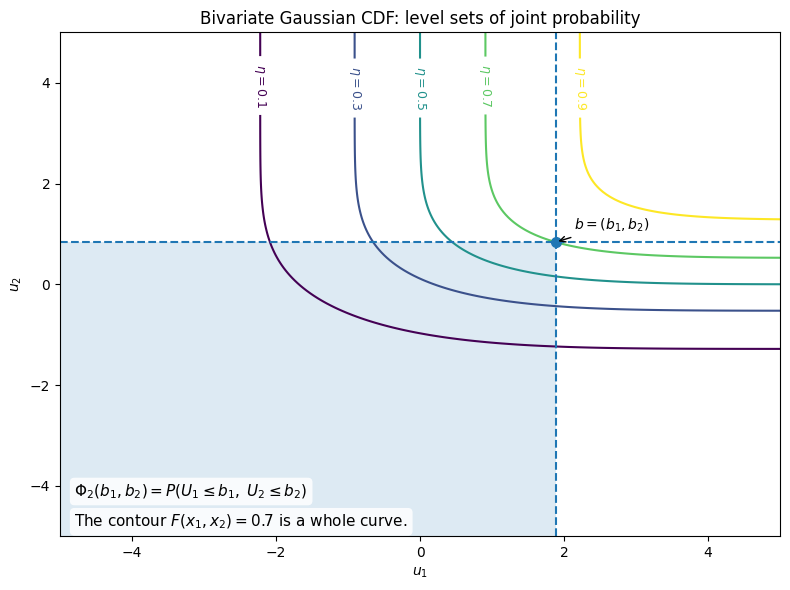

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# 2D Gaussian parameters
mu = np.array([0.0, 0.0])
rho = 0.3
Sigma = np.array([[3.0, rho],
                  [rho, 1.0]])
rv = multivariate_normal(mean=mu, cov=Sigma)

# Grid for the bivariate CDF
low , up = -5, +5
x = np.linspace(low, up, 200)
y = np.linspace(low, up, 200)
X, Y = np.meshgrid(x, y)
Z = np.empty_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = rv.cdf([X[i, j], Y[i, j]])

eta = 0.70
levels = [0.1, 0.3, 0.5, eta, 0.9]

fig, ax = plt.subplots(figsize=(8, 6))
cs = ax.contour(X, Y, Z, levels=levels)
ax.clabel(cs, inline=True, fontsize=9, fmt=lambda v: rf"$\eta={v:.1f}$")

# Pick one point directly from the eta contour
eta_index = levels.index(eta)
segments = cs.allsegs[eta_index]
seg = max(segments, key=lambda s: s.shape[0])  # longest contour segment
b = seg[len(seg) // 2]  # midpoint of the contour segment

# Draw the rectangle corresponding to F(b1,b2)=P(U1<=b1, U2<=b2)
ax.axvline(b[0], linestyle="--")
ax.axhline(b[1], linestyle="--")
ax.fill_between(x, low, b[1], where=(x <= b[0]), alpha=0.15)
ax.plot(b[0], b[1], marker="o", markersize=7)

ax.annotate(
    r"$b=(b_1,b_2)$",
    xy=(b[0], b[1]),
    xytext=(b[0] + 0.25, b[1] + 0.25),
    arrowprops=dict(arrowstyle="->")
)

ax.text(
    low+0.2, low+0.8,
    r"$\Phi_2(b_1,b_2)=P(U_1\leq b_1,\;U_2\leq b_2)$",
    fontsize=11,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, boxstyle="round,pad=0.3")
)

ax.text(
    low+0.2, low+0.2,
    r"The contour $F(x_1,x_2)=0.7$ is a whole curve.",
    fontsize=11,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, boxstyle="round,pad=0.3")
)
bbox=dict(facecolor="white", edgecolor="black", alpha=0.85, boxstyle="round,pad=0.3")
ax.set_xlabel(r"$u_1$")
ax.set_ylabel(r"$u_2$")
ax.set_title("Bivariate Gaussian CDF: level sets of joint probability")
ax.set_xlim(low , up)
ax.set_ylim(low , up)

plt.tight_layout()
plt.show()


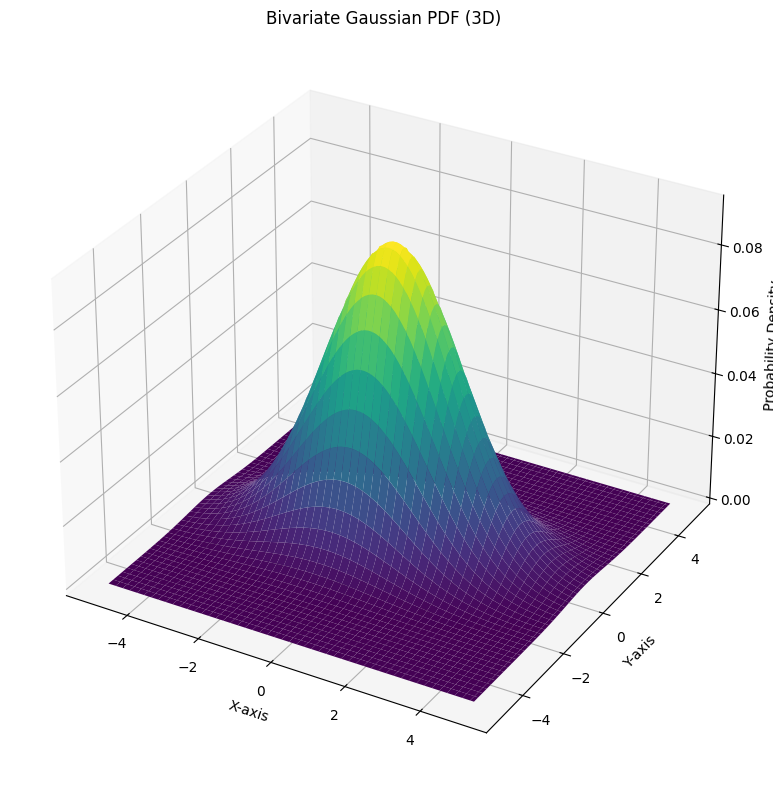

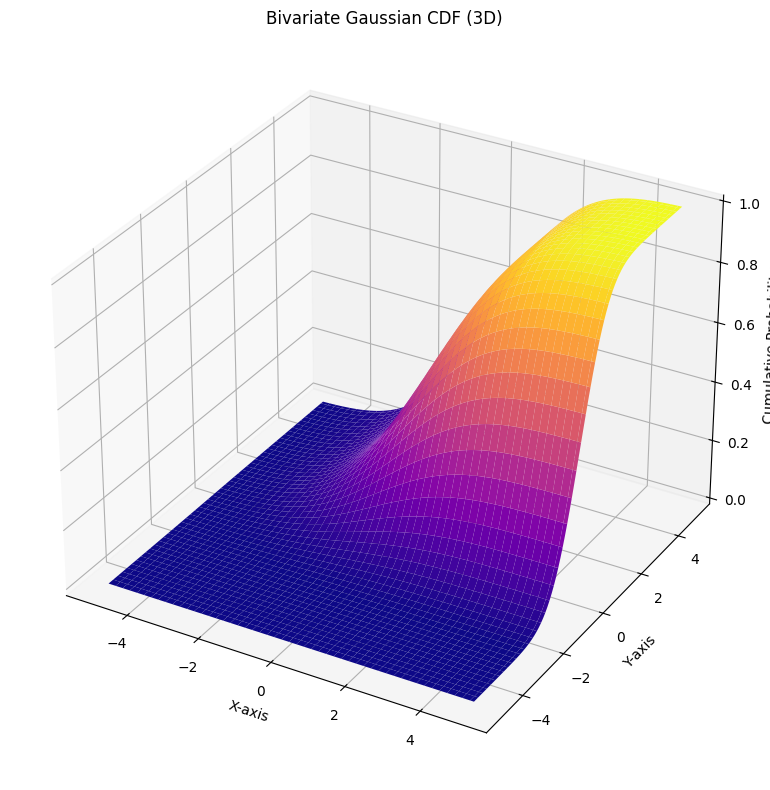

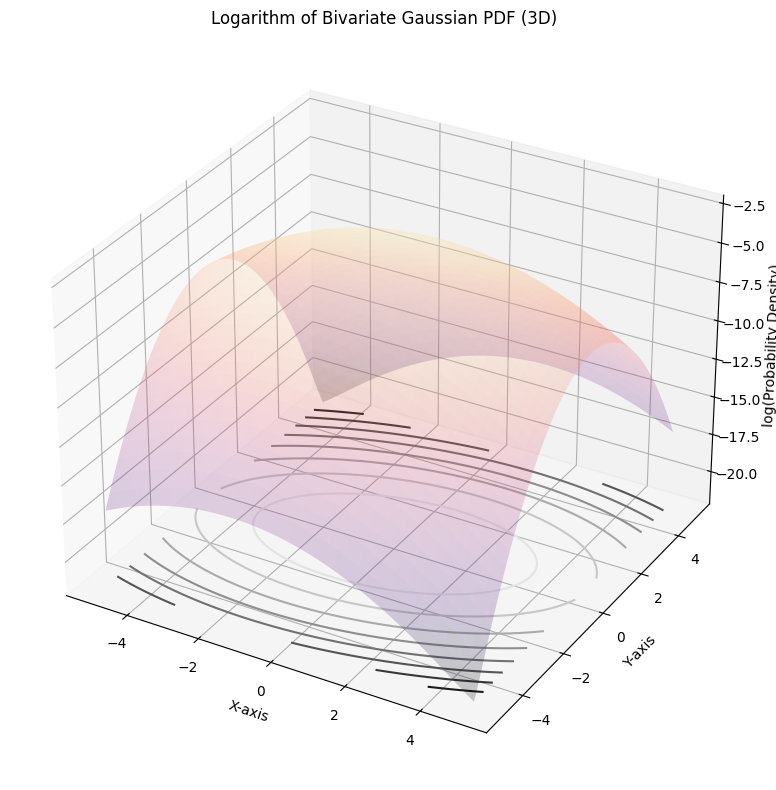

The first plot shows the 3D surface of the Bivariate Gaussian Probability Density Function (PDF).
The second plot displays the 3D surface of the Bivariate Gaussian Cumulative Distribution Function (CDF).
The third plot shows the logarithm of the PDF. Its characteristic inverted bowl shape demonstrates that the Gaussian PDF is log-concave, meaning its logarithm is a concave function.


In [12]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from mpl_toolkits.mplot3d import Axes3D

mu = np.array([0.0, 0.0])
rho = 0.3
Sigma = np.array([[3.0, rho],
                  [rho, 1.0]])
rv = multivariate_normal(mean=mu, cov=Sigma)

low, up = -5, +5
x = np.linspace(low, up, 100)
y = np.linspace(low, up, 100)
X, Y = np.meshgrid(x, y)

# Vectorized PDF evaluation (avoids nested loops)
pos = np.dstack((X, Y))
Z_pdf = rv.pdf(pos)

# --- 1. PDF ---
fig_pdf = plt.figure(figsize=(10, 8))
ax_pdf = fig_pdf.add_subplot(111, projection='3d')
ax_pdf.plot_surface(X, Y, Z_pdf, cmap='viridis')
ax_pdf.set_xlabel('X-axis')
ax_pdf.set_ylabel('Y-axis')
ax_pdf.set_zlabel('Probability Density')
ax_pdf.set_title('Bivariate Gaussian PDF (3D)')
plt.tight_layout()
plt.show()

# --- 2. CDF ---
Z_cdf = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z_cdf[i, j] = rv.cdf([X[i, j], Y[i, j]])

fig_cdf = plt.figure(figsize=(10, 8))
ax_cdf = fig_cdf.add_subplot(111, projection='3d')
ax_cdf.plot_surface(X, Y, Z_cdf, cmap='plasma')


ax_cdf.set_xlabel('X-axis')
ax_cdf.set_ylabel('Y-axis')
ax_cdf.set_zlabel('Cumulative Probability')
ax_cdf.set_title('Bivariate Gaussian CDF (3D)')
plt.tight_layout()
plt.show()

# --- 3. Log-concavity ---
epsilon = 1e-10
Z_log_pdf = np.log(Z_pdf + epsilon)

fig_log = plt.figure(figsize=(10, 8))
ax_log = fig_log.add_subplot(111, projection='3d')
ax_log.plot_surface(X, Y, Z_log_pdf, cmap='magma', alpha=0.2)


# Add iso-probability contours
levels = np.linspace(Z_log_pdf.min(), Z_log_pdf.max(), 10)
ax_log.contour(X, Y, Z_log_pdf, levels=levels, offset=Z_log_pdf.min(), cmap='gray')

ax_log.set_xlabel('X-axis')
ax_log.set_ylabel('Y-axis')
ax_log.set_zlabel('log(Probability Density)')
ax_log.set_title('Logarithm of Bivariate Gaussian PDF (3D)')
plt.tight_layout()
plt.show()

print("The first plot shows the 3D surface of the Bivariate Gaussian Probability Density Function (PDF).")
print("The second plot displays the 3D surface of the Bivariate Gaussian Cumulative Distribution Function (CDF).")
print("The third plot shows the logarithm of the PDF. Its characteristic inverted bowl shape demonstrates that the Gaussian PDF is log-concave, meaning its logarithm is a concave function.")

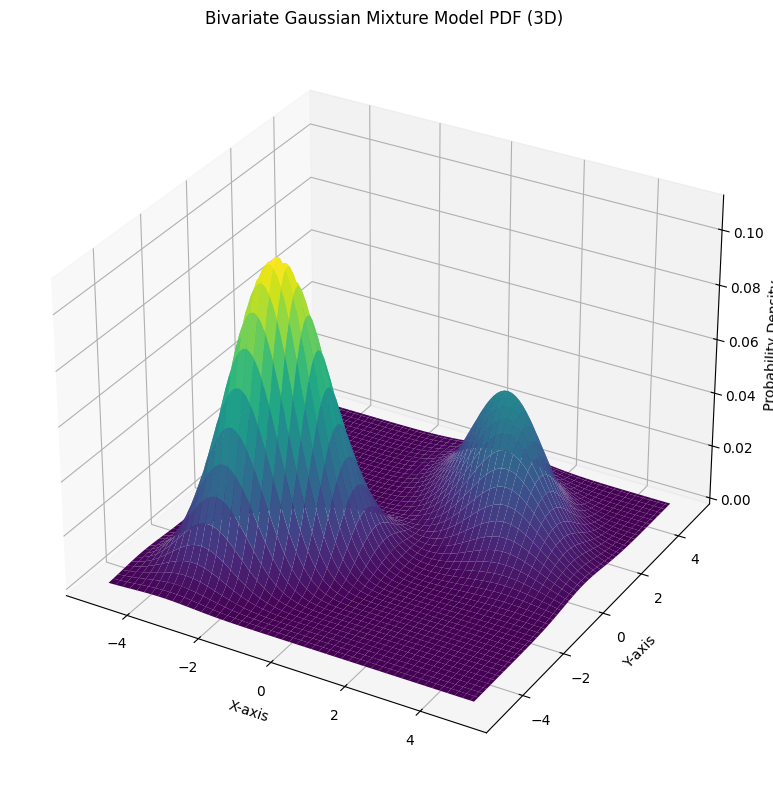

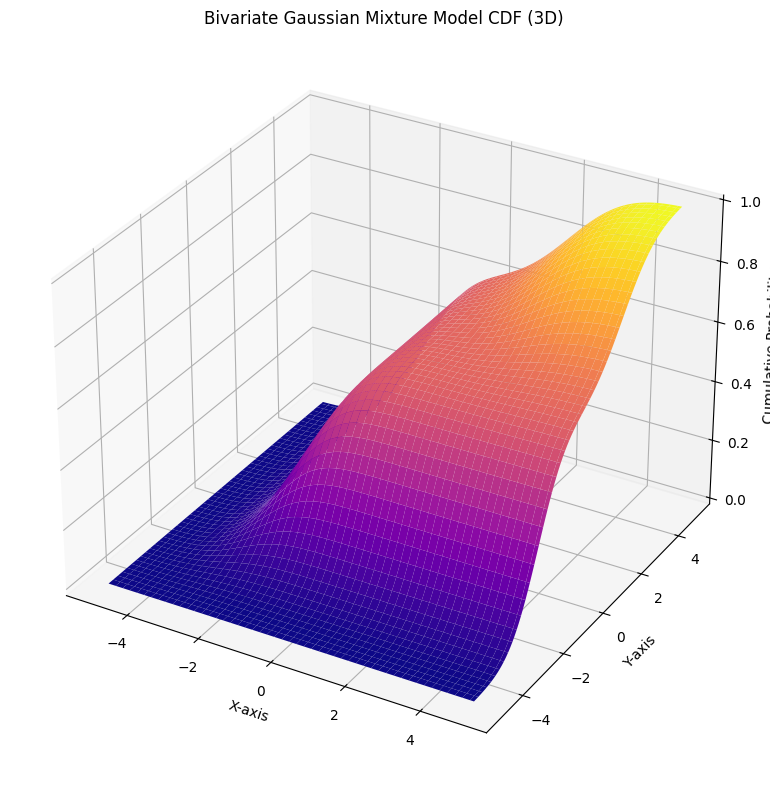

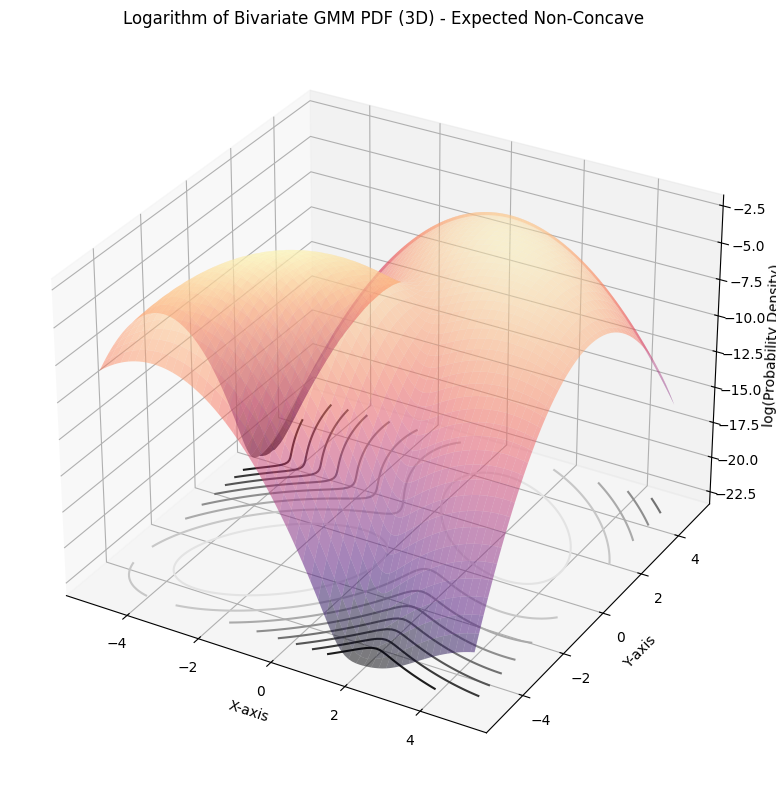

The first plot shows the 3D surface of the Bivariate Gaussian Mixture Model (GMM) Probability Density Function (PDF).
The second plot displays the 3D surface of the GMM Cumulative Distribution Function (CDF).
The third plot shows the logarithm of the GMM PDF. Observe that unlike a single Gaussian, this surface typically does not maintain a simple inverted bowl shape, demonstrating that a Gaussian mixture is generally not log-concave. You can see dips or 'valleys' between the peaks, indicating non-concavity.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from mpl_toolkits.mplot3d import Axes3D

# Define two Gaussian components for the GMM
# Component 1
mu1 = np.array([-2.0, -2.0])
Sigma1 = np.array([[1.0, 0.5],
                   [0.5, 1.0]])
rv1 = multivariate_normal(mean=mu1, cov=Sigma1)
weight1 = 0.6

# Component 2
mu2 = np.array([2.0, 2.0])
Sigma2 = np.array([[1.5, -0.8],
                   [-0.8, 1.5]])
rv2 = multivariate_normal(mean=mu2, cov=Sigma2)
weight2 = 0.4

# Create a grid for the 3D plots (reusing from previous cell for consistency)
low, up = -5, +5
x = np.linspace(low, up, 100)
y = np.linspace(low, up, 100)
X, Y = np.meshgrid(x, y)

# --- 1. Gaussian Mixture Model PDF in a 3D plot ---
Z_gmm_pdf = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        point = [X[i, j], Y[i, j]]
        Z_gmm_pdf[i, j] = weight1 * rv1.pdf(point) + weight2 * rv2.pdf(point)

fig_gmm_pdf = plt.figure(figsize=(10, 8))
ax_gmm_pdf = fig_gmm_pdf.add_subplot(111, projection='3d')
ax_gmm_pdf.plot_surface(X, Y, Z_gmm_pdf, cmap='viridis')
ax_gmm_pdf.set_xlabel('X-axis')
ax_gmm_pdf.set_ylabel('Y-axis')
ax_gmm_pdf.set_zlabel('Probability Density')
ax_gmm_pdf.set_title('Bivariate Gaussian Mixture Model PDF (3D)')
plt.tight_layout()
plt.show()

# --- 2. Gaussian Mixture Model CDF in a 3D plot ---
Z_gmm_cdf = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        point = [X[i, j], Y[i, j]]
        Z_gmm_cdf[i, j] = weight1 * rv1.cdf(point) + weight2 * rv2.cdf(point)

fig_gmm_cdf = plt.figure(figsize=(10, 8))
ax_gmm_cdf = fig_gmm_cdf.add_subplot(111, projection='3d')
ax_gmm_cdf.plot_surface(X, Y, Z_gmm_cdf, cmap='plasma')
ax_gmm_cdf.set_xlabel('X-axis')
ax_gmm_cdf.set_ylabel('Y-axis')
ax_gmm_cdf.set_zlabel('Cumulative Probability')
ax_gmm_cdf.set_title('Bivariate Gaussian Mixture Model CDF (3D)')
plt.tight_layout()
plt.show()

# --- 3. Logarithm of GMM PDF Demonstration (expected not to be concave) ---
epsilon = 1e-10 # To avoid log(0)
Z_gmm_log_pdf = np.log(Z_gmm_pdf + epsilon)

fig_gmm_log_pdf = plt.figure(figsize=(10, 8))
ax_gmm_log_pdf = fig_gmm_log_pdf.add_subplot(111, projection='3d')
ax_gmm_log_pdf.plot_surface(X, Y, Z_gmm_log_pdf, cmap='magma', alpha=0.5)

# Add iso-probability contours
levels = np.linspace(Z_gmm_log_pdf.min(), Z_gmm_log_pdf.max(), 10)
ax_gmm_log_pdf.contour(X, Y, Z_gmm_log_pdf, levels=levels, offset=Z_gmm_log_pdf.min(), cmap='gray')

ax_gmm_log_pdf.set_xlabel('X-axis')
ax_gmm_log_pdf.set_ylabel('Y-axis')
ax_gmm_log_pdf.set_zlabel('log(Probability Density)')
ax_gmm_log_pdf.set_title('Logarithm of Bivariate GMM PDF (3D) - Expected Non-Concave')
plt.tight_layout()
plt.show()

print("The first plot shows the 3D surface of the Bivariate Gaussian Mixture Model (GMM) Probability Density Function (PDF).")
print("The second plot displays the 3D surface of the GMM Cumulative Distribution Function (CDF).")
print("The third plot shows the logarithm of the GMM PDF. Observe that unlike a single Gaussian, this surface typically does not maintain a simple inverted bowl shape, demonstrating that a Gaussian mixture is generally not log-concave. You can see dips or 'valleys' between the peaks, indicating non-concavity.")